# Headers

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler


# Transformer Network Model

The Transformer model is a revolutionary architecture in deep learning, primarily designed for handling sequential data, particularly in the context of natural language processing (NLP). Introduced in the seminal paper "Attention Is All You Need" by Vaswani et al. in 2017, the Transformer model leverages a mechanism called self-attention to effectively manage dependencies across different parts of the input sequence without relying on recurrent or convolutional structures.

In [ ]:

class TimeSeriesTransformer(nn.Module):
    def __init__(self, feature_dim, num_heads, num_layers, hidden_dim):
        super(TimeSeriesTransformer, self).__init__()
        self.input_layer = nn.Linear(feature_dim, hidden_dim)
        self.transformer = nn.Transformer(
            d_model=hidden_dim, nhead=num_heads, num_encoder_layers=num_layers, num_decoder_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, 1)  # Predict a single value

    def forward(self, src):
        src = self.input_layer(src)
        output = self.transformer(src, src)  # Self-attention on src
        return self.fc(output[:, -1, :])  # Predict the last value


# Reliance

In [ ]:
ticker_symbol = "RELIANCE.NS"

## 1 minute

In [ ]:
# df = yf.download(tickers=ticker_symbol, period="5d", interval="1m")
# df = df.reset_index()
# df

start_date = "2025-01-06"
end_date = "2025-01-10"

# Download the data for the specified date range with 1-minute intervals
df = yf.download(tickers=ticker_symbol, start=start_date, end=end_date, interval="1m")

# Reset the index to make the "Datetime" index a column
df = df.reset_index()

# Display the DataFrame
print(df)

[*********************100%***********************]  1 of 1 completed

Price                   Datetime        Close         High          Low  \
Ticker                            RELIANCE.NS  RELIANCE.NS  RELIANCE.NS   
0      2025-01-06 03:45:00+00:00  1251.349976  1253.400024  1251.349976   
1      2025-01-06 03:46:00+00:00  1252.400024  1253.699951  1250.150024   
2      2025-01-06 03:47:00+00:00  1252.599976  1252.599976  1252.599976   
3      2025-01-06 03:48:00+00:00  1249.300049  1251.099976  1249.099976   
4      2025-01-06 03:49:00+00:00  1249.599976  1250.300049  1249.449951   
...                          ...          ...          ...          ...   
1494   2025-01-09 09:55:00+00:00  1256.300049  1257.199951  1256.300049   
1495   2025-01-09 09:56:00+00:00  1255.900024  1257.000000  1255.699951   
1496   2025-01-09 09:57:00+00:00  1256.650024  1256.750000  1256.199951   
1497   2025-01-09 09:58:00+00:00  1256.699951  1256.699951  1256.000000   
1498   2025-01-09 09:59:00+00:00  1257.000000  1257.449951  1256.500000   

Price          Open     

### Close value

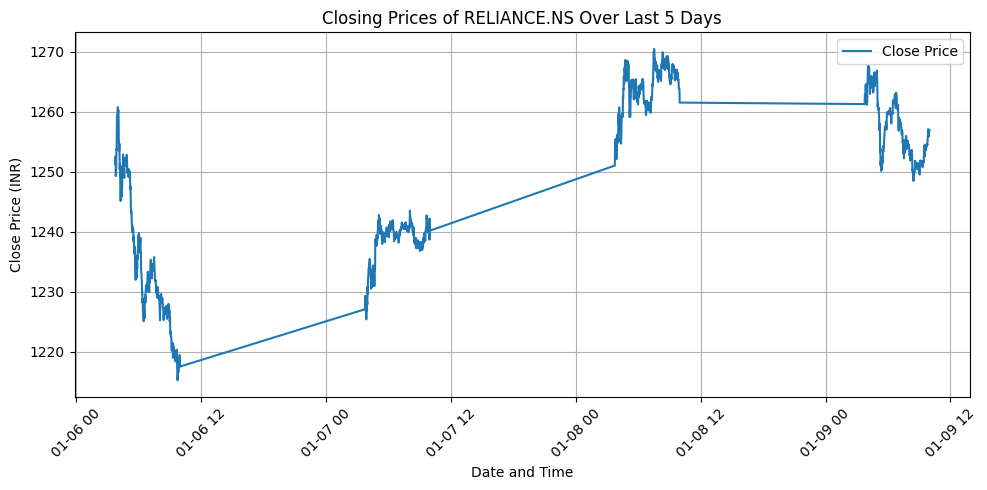

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df['Datetime'], df['Close'], label='Close Price')
plt.title(f'Closing Prices of {ticker_symbol} Over Last 5 Days')
plt.xlabel('Date and Time')
plt.ylabel('Close Price (INR)')
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

### Data Split

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Scale data before splitting into train and test
scaled_data = scaler.fit_transform(df[['Close']].values)

# Train-test split
train_size = int(len(scaled_data) * 0.7)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# Prepare input-output sequences
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

SEQUENCE_LENGTH = 30  # Keep sequences long enough to capture trends
X_train, y_train = create_sequences(train_data, SEQUENCE_LENGTH)
X_test, y_test = create_sequences(test_data, SEQUENCE_LENGTH)


<ipython-input-6-b928447d2d92>:19: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


### Model Parameters

In [ ]:
# Model Hyperparameters
feature_dim = X_train.shape[2]  # Number of input features
num_heads = 4
num_layers = 2
hidden_dim = 128
dropout = 0.1

model = TimeSeriesTransformer(
    feature_dim=feature_dim,
    num_heads=2,  # Reduce attention heads
    num_layers=1,  # Fewer layers
    hidden_dim=64,  # Smaller hidden dimension
)


### Train the model

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

# Training loop
epochs = 200
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")


Epoch [10/200], Loss: 0.024451
Epoch [20/200], Loss: 0.023008
Epoch [30/200], Loss: 0.013330
Epoch [40/200], Loss: 0.011248
Epoch [50/200], Loss: 0.008793
Epoch [60/200], Loss: 0.007151
Epoch [70/200], Loss: 0.006688
Epoch [80/200], Loss: 0.005274
Epoch [90/200], Loss: 0.004990
Epoch [100/200], Loss: 0.004688
Epoch [110/200], Loss: 0.004175
Epoch [120/200], Loss: 0.004138
Epoch [130/200], Loss: 0.003926
Epoch [140/200], Loss: 0.003860
Epoch [150/200], Loss: 0.003637
Epoch [160/200], Loss: 0.003447
Epoch [170/200], Loss: 0.003488
Epoch [180/200], Loss: 0.003493
Epoch [190/200], Loss: 0.003147
Epoch [200/200], Loss: 0.003023


### Tast the model

In [ ]:
# Make predictions
model.eval()
with torch.no_grad():
    predictions = model(X_test).numpy()

# Inverse transform the predictions
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.numpy())

### Predicted vs Actual:

This plot shows how well a regression model performs. If the predictions perfectly match the actual values, the points should align along a straight line with a slope of one. The closer the points cluster around this line, the more accurate the model's predictions are.

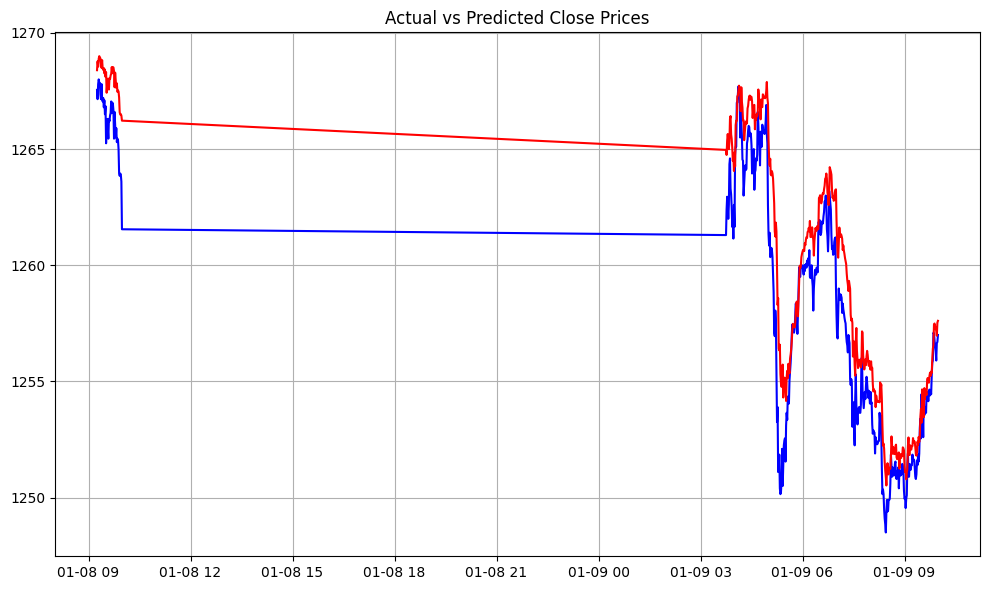

<Figure size 640x480 with 0 Axes>

In [ ]:
datetime_test = df['Datetime'][-len(y_test_actual):]

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(datetime_test, y_test_actual, label="Actual", color="blue")
plt.plot(datetime_test, predictions, label="Predicted", color="red")
plt.title("Actual vs Predicted Close Prices")
plt.grid()
plt.tight_layout()
plt.show()
plt.savefig('Transformer_Reliance_1min.png')

### Residual plot:

This plot offering insight into the relationship between observed and predicted values. Residuals distributed randomly around y = 0 indicate a well-captured data structure, whereas patterns or trends indicate model inadequacy. A good model will have residuals dispersed around zero, shown by a red dashed line. This plot is crucial tool in regression analysis.

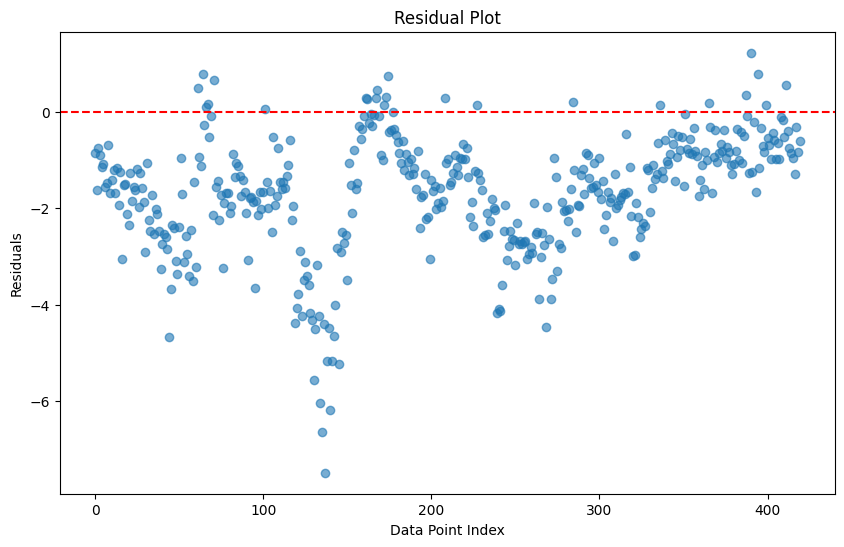

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

# Step 1: Calculate residuals
residuals = y_test_actual.flatten() - predictions.flatten()

# Step 2: Residual Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(range(len(residuals)), residuals, alpha=0.6)
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Residual Plot")
plt.xlabel("Data Point Index")
plt.ylabel("Residuals")
plt.show()
plt.savefig('Transformer_Reliance_1min_residual.png')

### Residual Histogram

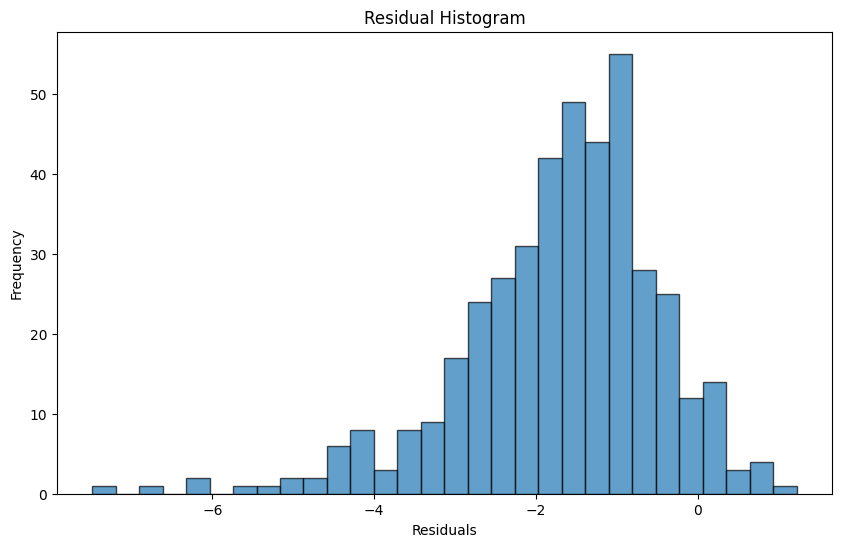

<Figure size 640x480 with 0 Axes>

In [ ]:
# Step 3: Residual Histogram
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30,  edgecolor="black", alpha=0.7)
plt.title("Residual Histogram")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()
plt.savefig('Transformer_Reliance_1min_histogram.png')

### Errors

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate MAPE
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100
print(f"Mean Absolute Percentage Error: {mape:.2f}%")

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print(f"Root Mean Squared Error: {rmse}")

# Calculate MAE
mae = mean_absolute_error(y_test_actual, predictions)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Percentage Error: 0.14%
Root Mean Squared Error: 2.098550446084621
Mean Absolute Error: 1.7375258207321167


## 2 minutes

In [ ]:
# df = yf.download(tickers=ticker_symbol, period="5d", interval="1m")
# df = df.reset_index()
# df

start_date = "2025-01-06"
end_date = "2025-02-06"

# Download the data for the specified date range with 1-minute intervals
df = yf.download(tickers=ticker_symbol, start=start_date, end=end_date, interval="2m")

# Reset the index to make the "Datetime" index a column
df = df.reset_index()

# Display the DataFrame
print(df)

[*********************100%***********************]  1 of 1 completed

Price                   Datetime        Close         High          Low  \
Ticker                            RELIANCE.NS  RELIANCE.NS  RELIANCE.NS   
0      2025-01-06 03:45:00+00:00  1252.400024  1253.699951  1250.150024   
1      2025-01-06 03:47:00+00:00  1249.300049  1252.599976  1249.099976   
2      2025-01-06 03:49:00+00:00  1249.699951  1250.300049  1248.150024   
3      2025-01-06 03:51:00+00:00  1253.800049  1254.000000  1250.050049   
4      2025-01-06 03:53:00+00:00  1256.300049  1256.750000  1252.250000   
..                           ...          ...          ...          ...   
935    2025-01-10 09:51:00+00:00  1242.949951  1242.949951  1242.050049   
936    2025-01-10 09:53:00+00:00  1242.750000  1243.199951  1242.500000   
937    2025-01-10 09:55:00+00:00  1243.349976  1243.400024  1242.699951   
938    2025-01-10 09:57:00+00:00  1244.699951  1244.800049  1243.349976   
939    2025-01-10 09:59:00+00:00  1245.000000  1245.550049  1244.000000   

Price          Open     

### Close value

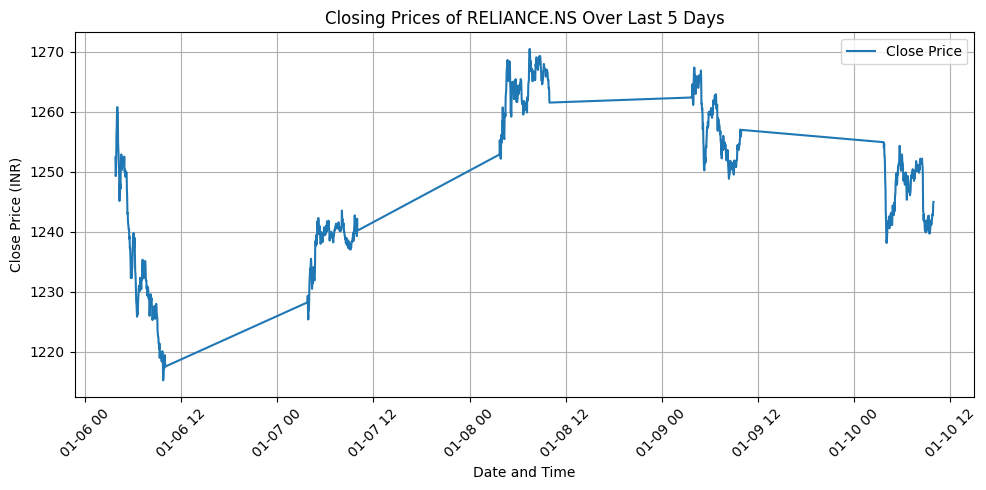

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df['Datetime'], df['Close'], label='Close Price')
plt.title(f'Closing Prices of {ticker_symbol} Over Last 5 Days')
plt.xlabel('Date and Time')
plt.ylabel('Close Price (INR)')
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

### Data Split

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Scale data before splitting into train and test
scaled_data = scaler.fit_transform(df[['Close']].values)

# Train-test split
train_size = int(len(scaled_data) * 0.7)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# Prepare input-output sequences
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

SEQUENCE_LENGTH = 30  # Keep sequences long enough to capture trends
X_train, y_train = create_sequences(train_data, SEQUENCE_LENGTH)
X_test, y_test = create_sequences(test_data, SEQUENCE_LENGTH)


### Model Parameters

In [ ]:
# Model Hyperparameters
feature_dim = X_train.shape[2]  # Number of input features
num_heads = 4
num_layers = 2
hidden_dim = 128
dropout = 0.1

model = TimeSeriesTransformer(
    feature_dim=feature_dim,
    num_heads=2,  # Reduce attention heads
    num_layers=1,  # Fewer layers
    hidden_dim=64,  # Smaller hidden dimension
)


### Train the model

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

# Training loop
epochs = 200
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")


Epoch [10/100], Loss: 0.040462
Epoch [20/100], Loss: 0.028062
Epoch [30/100], Loss: 0.018099
Epoch [40/100], Loss: 0.014326
Epoch [50/100], Loss: 0.011711
Epoch [60/100], Loss: 0.010590
Epoch [70/100], Loss: 0.007366
Epoch [80/100], Loss: 0.007569
Epoch [90/100], Loss: 0.006685
Epoch [100/100], Loss: 0.005745


### Train the model

In [ ]:
# Make predictions
model.eval()
with torch.no_grad():
    predictions = model(X_test).numpy()

# Inverse transform the predictions
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.numpy())

### Predicted vs Actual:

This plot shows how well a regression model performs. If the predictions perfectly match the actual values, the points should align along a straight line with a slope of one. The closer the points cluster around this line, the more accurate the model's predictions are.

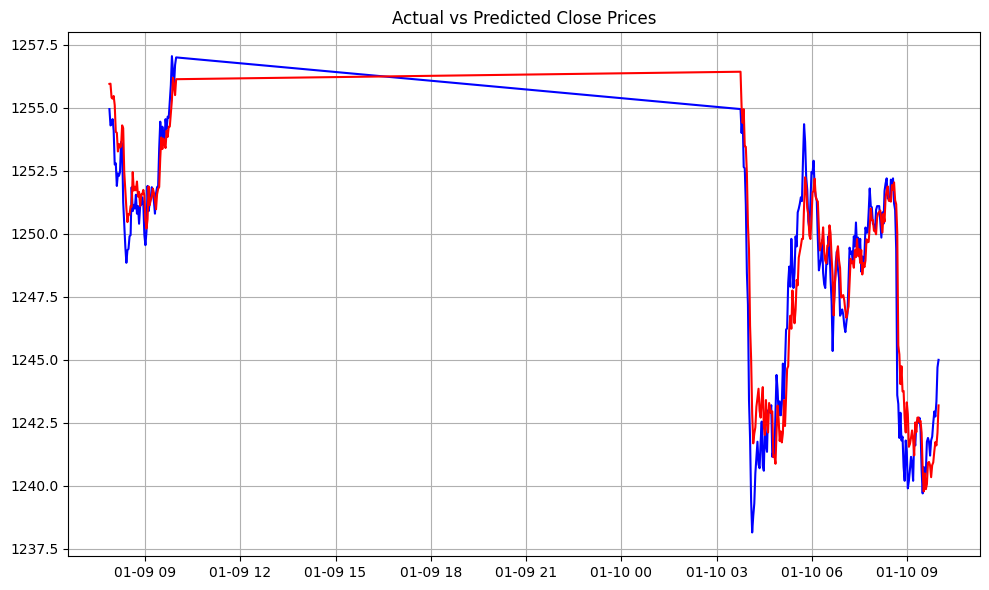

In [ ]:
datetime_test = df['Datetime'][-len(y_test_actual):]

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(datetime_test, y_test_actual, label="Actual", color="blue")
plt.plot(datetime_test, predictions, label="Predicted", color="red")
plt.title("Actual vs Predicted Close Prices")
plt.grid()
plt.tight_layout()
plt.savefig('Transformer_Reliance_2min.png')
plt.show()

### Residual plot:

This plot offering insight into the relationship between observed and predicted values. Residuals distributed randomly around y = 0 indicate a well-captured data structure, whereas patterns or trends indicate model inadequacy. A good model will have residuals dispersed around zero, shown by a red dashed line. This plot is crucial tool in regression analysis.

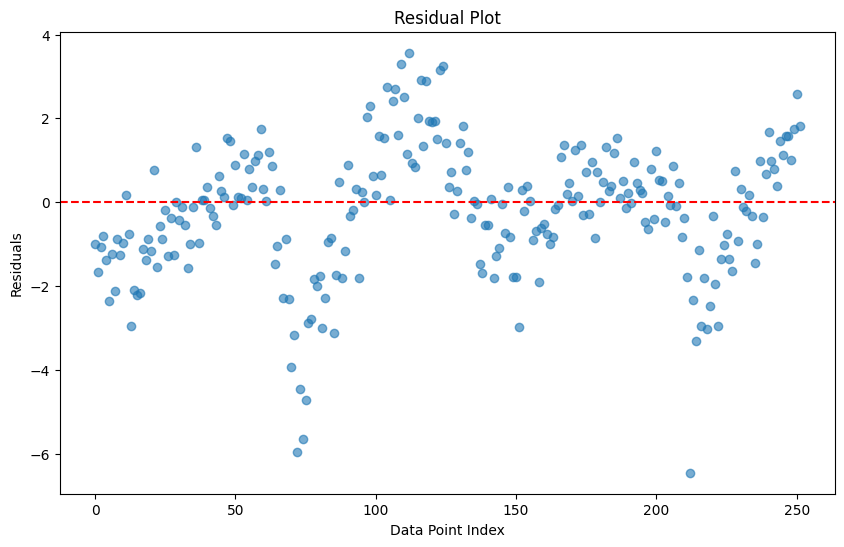

In [ ]:
import matplotlib.pyplot as plt

# Calculate residuals
residuals = y_test_actual.flatten() - predictions.flatten()

# Residual Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(range(len(residuals)), residuals, alpha=0.6)
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Residual Plot")
plt.xlabel("Data Point Index")
plt.ylabel("Residuals")
plt.savefig('Transformer_Reliance_2min_residual.png')
plt.show()

### Residual Histogram

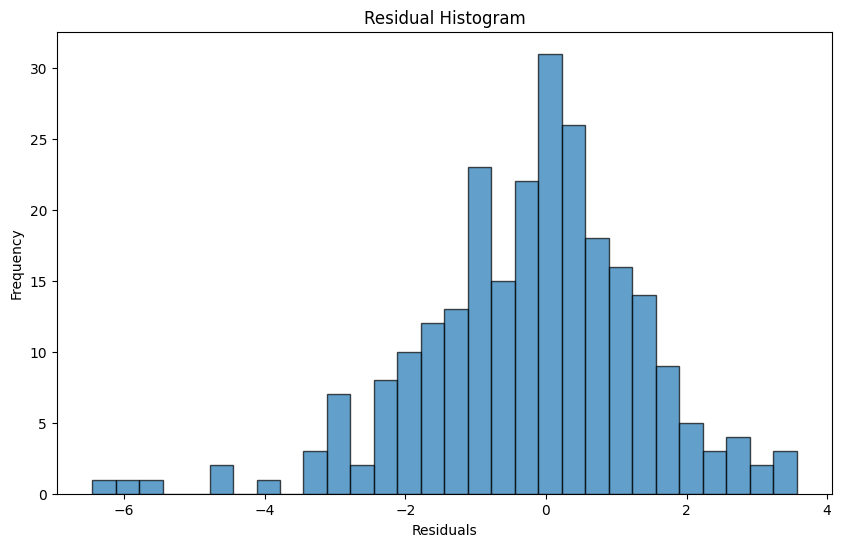

In [ ]:
# Residual Histogram
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor="black", alpha=0.7)
plt.title("Residual Histogram")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.savefig('Transformer_Reliance_2min_histogram.png')
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate MAPE
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100
print(f"Mean Absolute Percentage Error: {mape:.2f}%")

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print(f"Root Mean Squared Error: {rmse}")

# Calculate MAE
mae = mean_absolute_error(y_test_actual, predictions)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Percentage Error: 0.09%
Root Mean Squared Error: 1.5881213856865755
Mean Absolute Error: 1.183795690536499


## 1 day

In [ ]:
df = yf.download(tickers=ticker_symbol)
df = df.reset_index()
df

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
0,1996-01-01,3.750517,3.756897,3.712237,3.736846,104121369
1,1996-01-02,3.721350,3.759630,3.694007,3.741402,168743308
2,1996-01-03,3.749605,3.954675,3.741402,3.782416,209323879
3,1996-01-04,3.714971,3.725908,3.664843,3.714060,216900264
4,1996-01-05,3.689451,3.700388,3.657551,3.700388,166708467
...,...,...,...,...,...,...
7284,2025-01-06,1218.000000,1262.000000,1215.000000,1253.949951,14816766
7285,2025-01-07,1240.849976,1244.500000,1221.250000,1222.000000,10070505
7286,2025-01-08,1265.500000,1271.050049,1245.349976,1249.000000,19346579


### Close value

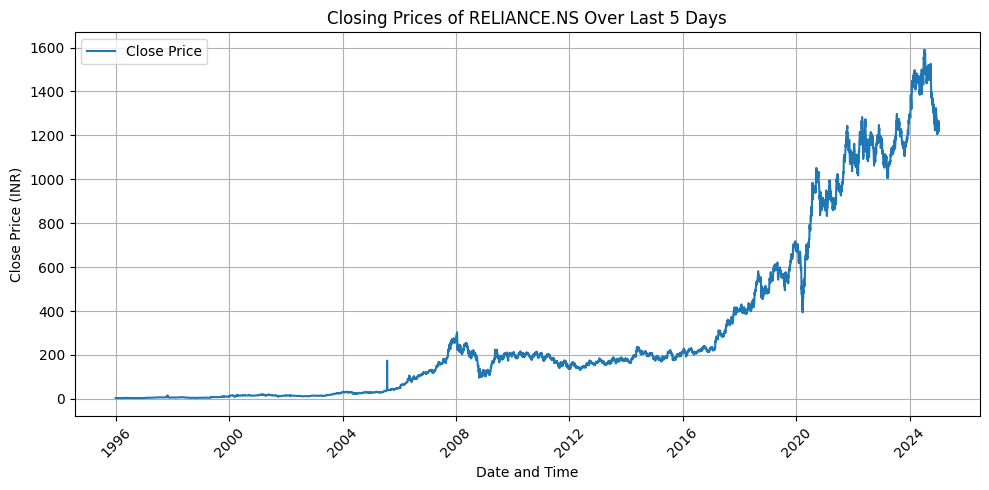

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.title(f'Closing Prices of {ticker_symbol} Over Last 5 Days')
plt.xlabel('Date and Time')
plt.ylabel('Close Price (INR)')
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

### Data Split

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Scale data before splitting into train and test
scaled_data = scaler.fit_transform(df[['Close']].values)

# Train-test split
train_size = int(len(scaled_data) * 0.7)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# Prepare input-output sequences
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

SEQUENCE_LENGTH = 20  # Keep sequences long enough to capture trends
X_train, y_train = create_sequences(train_data, SEQUENCE_LENGTH)
X_test, y_test = create_sequences(test_data, SEQUENCE_LENGTH)

### Model Parameters

In [ ]:
# Model Hyperparameters
feature_dim = X_train.shape[2]  # Number of input features
num_heads = 4
num_layers = 2
hidden_dim = 128
dropout = 0.1

model = TimeSeriesTransformer(
    feature_dim=feature_dim,
    num_heads=2,  # Reduce attention heads
    num_layers=1,  # Fewer layers
    hidden_dim=64,  # Smaller hidden dimension
)

### Train the model

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

# Training loop
epochs = 100
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")


Epoch [10/50], Loss: 0.022750
Epoch [20/50], Loss: 0.017645
Epoch [30/50], Loss: 0.009218
Epoch [40/50], Loss: 0.007979
Epoch [50/50], Loss: 0.006042


### Train the model

In [ ]:
# Make predictions
model.eval()
with torch.no_grad():
    predictions = model(X_test).numpy()

# Inverse transform the predictions
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.numpy())

### Predicted vs Actual:

This plot shows how well a regression model performs. If the predictions perfectly match the actual values, the points should align along a straight line with a slope of one. The closer the points cluster around this line, the more accurate the model's predictions are.

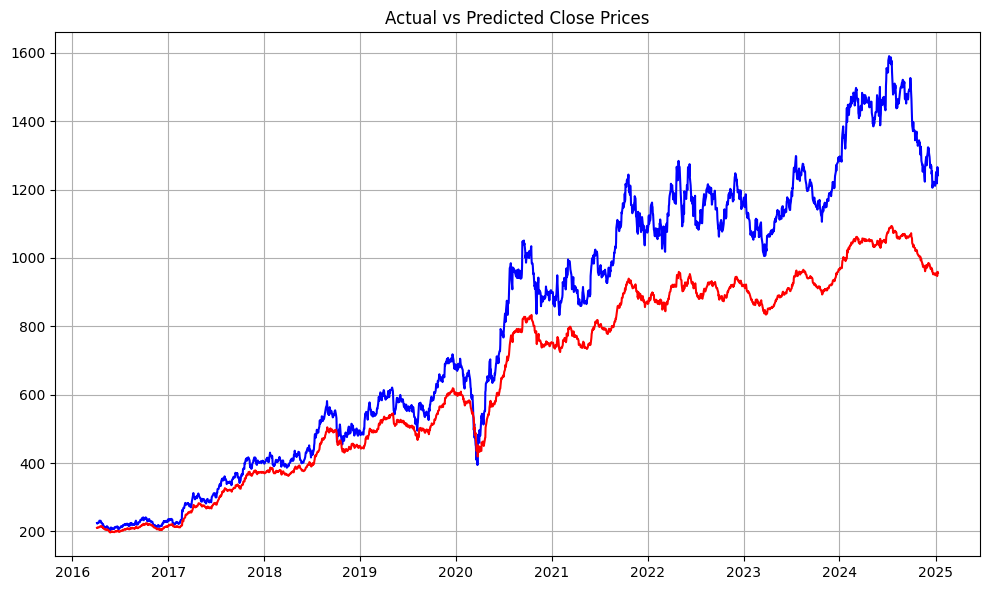

In [ ]:
datetime_test = df['Date'][-len(y_test_actual):]

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(datetime_test, y_test_actual, label="Actual", color="blue")
plt.plot(datetime_test, predictions, label="Predicted", color="red")
plt.title("Actual vs Predicted Close Prices")
plt.grid()
plt.tight_layout()
plt.savefig('transformer_Reliance_1day.png')
plt.show()

### Residual plot:

This plot offering insight into the relationship between observed and predicted values. Residuals distributed randomly around y = 0 indicate a well-captured data structure, whereas patterns or trends indicate model inadequacy. A good model will have residuals dispersed around zero, shown by a red dashed line. This plot is crucial tool in regression analysis.

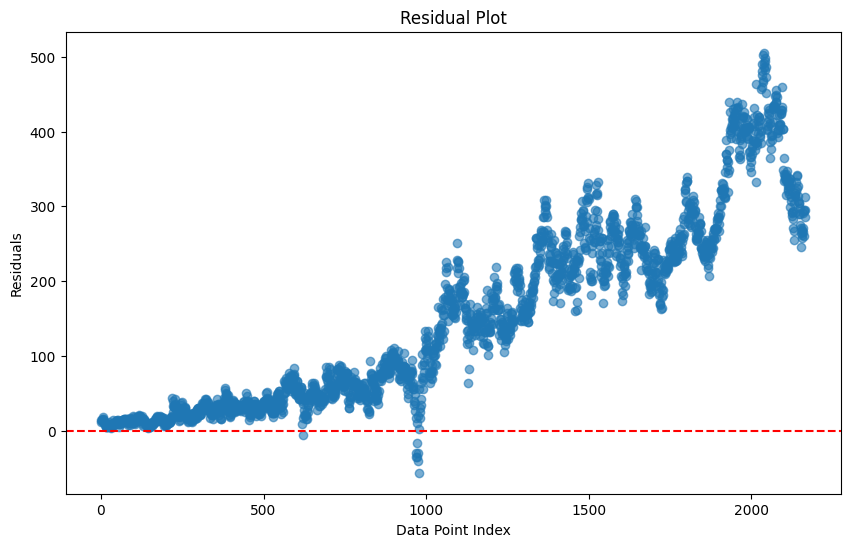

In [ ]:
import matplotlib.pyplot as plt

# Calculate residuals
residuals = y_test_actual.flatten() - predictions.flatten()

# Residual Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(range(len(residuals)), residuals, alpha=0.6)
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Residual Plot")
plt.xlabel("Data Point Index")
plt.ylabel("Residuals")
plt.savefig('transfomer_Reliance_1day_residual.png')
plt.show()

### Residual Histogram

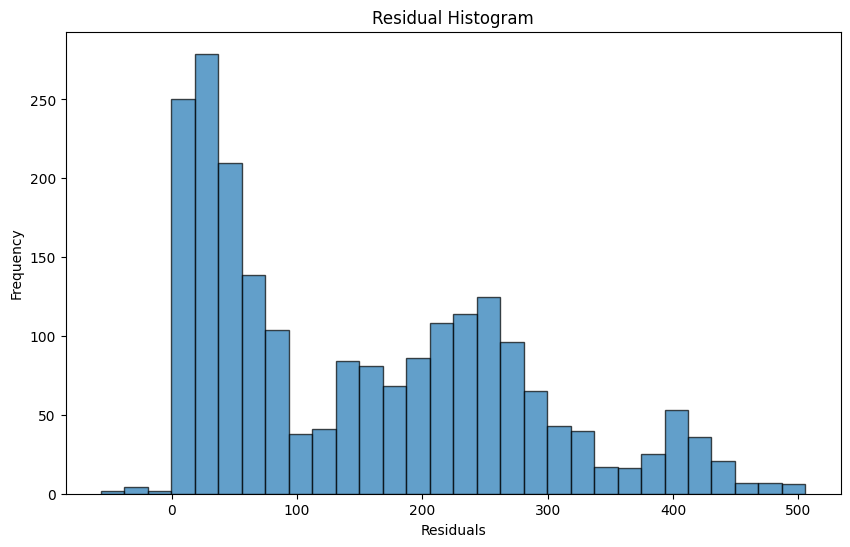

In [ ]:
# Residual Histogram
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor="black", alpha=0.7)
plt.title("Residual Histogram")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.savefig('GAN_Reliance_2min_histogram.png')
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate MAPE
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100
print(f"Mean Absolute Percentage Error: {mape:.2f}%")

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print(f"Root Mean Squared Error: {rmse}")

# Calculate MAE
mae = mean_absolute_error(y_test_actual, predictions)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Percentage Error: 15.42%
Root Mean Squared Error: 196.5291207747595
Mean Absolute Error: 152.2771453857422


# TCS

In [ ]:
ticker_symbol = "TCS.NS"

## 1 minute

In [ ]:
# df = yf.download(tickers=ticker_symbol, period="5d", interval="1m")
# df = df.reset_index()
# df

start_date = "2025-01-06"
end_date = "2025-01-10"

# Download the data for the specified date range with 1-minute intervals
df = yf.download(tickers=ticker_symbol, start=start_date, end=end_date, interval="1m")

# Reset the index to make the "Datetime" index a column
df = df.reset_index()

# Display the DataFrame
print(df)

[*********************100%***********************]  1 of 1 completed

Price                   Datetime        Close         High          Low  \
Ticker                                 TCS.NS       TCS.NS       TCS.NS   
0      2025-01-06 03:45:00+00:00  4115.799805  4117.899902  4107.500000   
1      2025-01-06 03:46:00+00:00  4114.000000  4119.399902  4114.000000   
2      2025-01-06 03:47:00+00:00  4123.850098  4123.850098  4114.049805   
3      2025-01-06 03:48:00+00:00  4125.750000  4128.149902  4121.100098   
4      2025-01-06 03:49:00+00:00  4126.649902  4132.500000  4123.049805   
...                          ...          ...          ...          ...   
1493   2025-01-09 09:55:00+00:00  4032.600098  4039.699951  4032.600098   
1494   2025-01-09 09:56:00+00:00  4037.550049  4037.649902  4032.149902   
1495   2025-01-09 09:57:00+00:00  4038.750000  4038.850098  4035.699951   
1496   2025-01-09 09:58:00+00:00  4047.500000  4047.500000  4038.050049   
1497   2025-01-09 09:59:00+00:00  4044.000000  4045.000000  4041.149902   

Price          Open Volu

### Close value

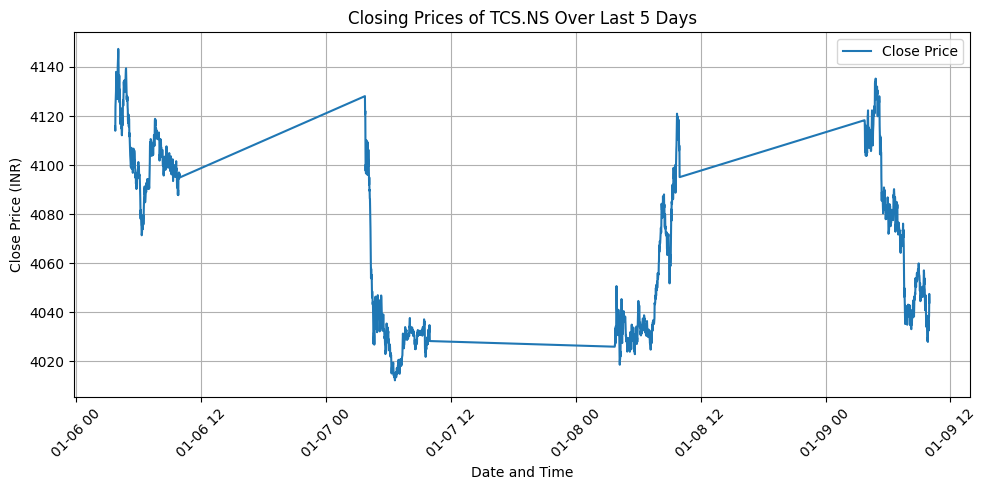

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df['Datetime'], df['Close'], label='Close Price')
plt.title(f'Closing Prices of {ticker_symbol} Over Last 5 Days')
plt.xlabel('Date and Time')
plt.ylabel('Close Price (INR)')
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

### Data Split

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Scale data before splitting into train and test
scaled_data = scaler.fit_transform(df[['Close']].values)

# Train-test split
train_size = int(len(scaled_data) * 0.7)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# Prepare input-output sequences
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

SEQUENCE_LENGTH = 30  # Keep sequences long enough to capture trends
X_train, y_train = create_sequences(train_data, SEQUENCE_LENGTH)
X_test, y_test = create_sequences(test_data, SEQUENCE_LENGTH)


### Model Parameters

In [ ]:
# Model Hyperparameters
feature_dim = X_train.shape[2]  # Number of input features
num_heads = 4
num_layers = 2
hidden_dim = 128
dropout = 0.1

model = TimeSeriesTransformer(
    feature_dim=feature_dim,
    num_heads=2,  # Reduce attention heads
    num_layers=1,  # Fewer layers
    hidden_dim=64,  # Smaller hidden dimension
)


### Train the model

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

# Training loop
epochs = 100
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")


Epoch [10/100], Loss: 0.027203
Epoch [20/100], Loss: 0.020871
Epoch [30/100], Loss: 0.012250
Epoch [40/100], Loss: 0.011875
Epoch [50/100], Loss: 0.007866
Epoch [60/100], Loss: 0.006857
Epoch [70/100], Loss: 0.006088
Epoch [80/100], Loss: 0.005226
Epoch [90/100], Loss: 0.004685
Epoch [100/100], Loss: 0.004223


### Tast the model

In [ ]:
# Make predictions
model.eval()
with torch.no_grad():
    predictions = model(X_test).numpy()

# Inverse transform the predictions
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.numpy())

### Predicted vs Actual:

This plot shows how well a regression model performs. If the predictions perfectly match the actual values, the points should align along a straight line with a slope of one. The closer the points cluster around this line, the more accurate the model's predictions are.

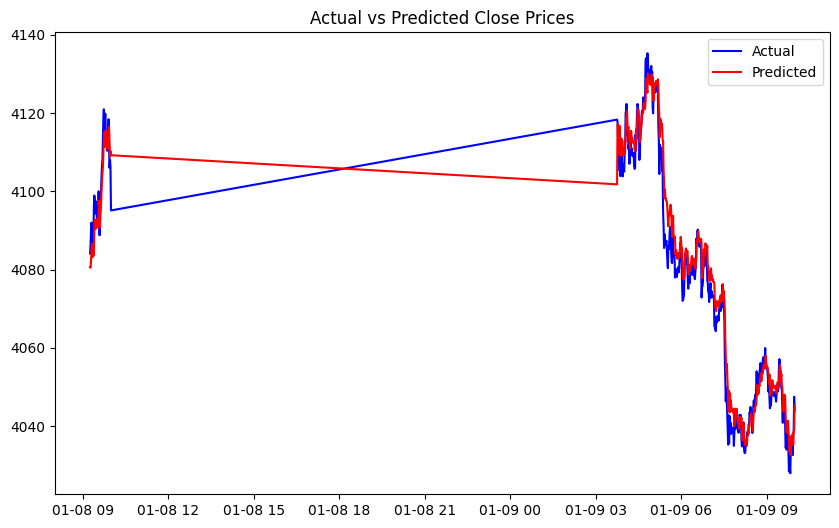

In [ ]:
datetime_test = df['Datetime'][-len(y_test_actual):]

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(datetime_test, y_test_actual, label="Actual", color="blue")
plt.plot(datetime_test, predictions, label="Predicted", color="red")
plt.title("Actual vs Predicted Close Prices")
plt.legend()
plt.show()

### Residual plot:

This plot offering insight into the relationship between observed and predicted values. Residuals distributed randomly around y = 0 indicate a well-captured data structure, whereas patterns or trends indicate model inadequacy. A good model will have residuals dispersed around zero, shown by a red dashed line. This plot is crucial tool in regression analysis.

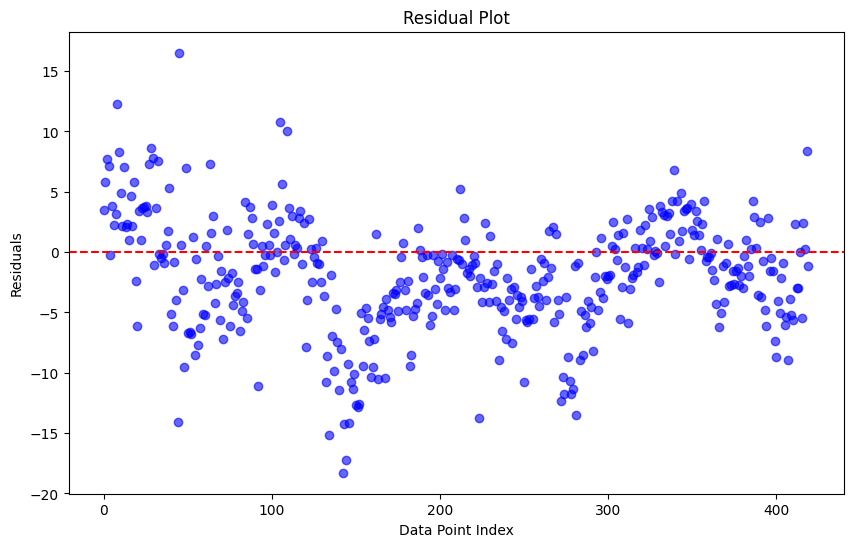

In [ ]:
import matplotlib.pyplot as plt

# Step 1: Calculate residuals
residuals = y_test_actual.flatten() - predictions.flatten()

# Step 2: Residual Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(range(len(residuals)), residuals, color="blue", alpha=0.6)
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Residual Plot")
plt.xlabel("Data Point Index")
plt.ylabel("Residuals")
plt.show()

### Residual Histogram

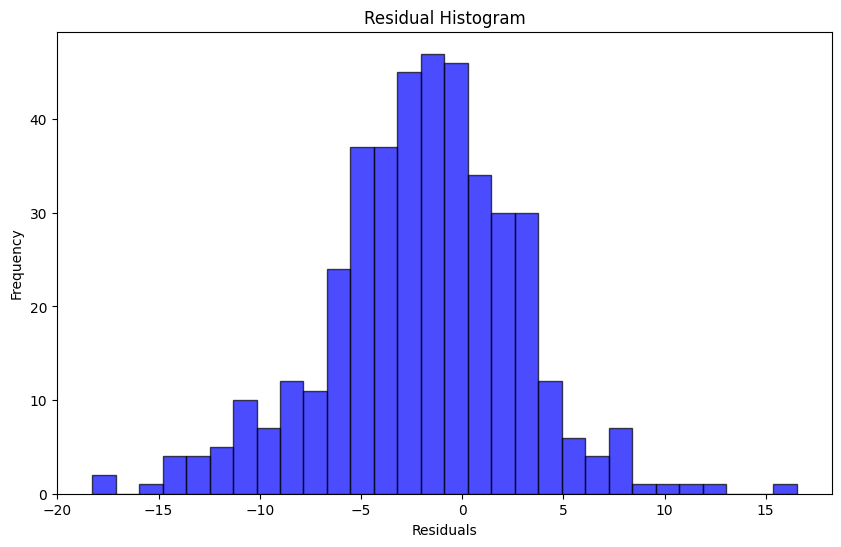

In [ ]:
# Step 3: Residual Histogram
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, color="blue", edgecolor="black", alpha=0.7)
plt.title("Residual Histogram")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate MAPE
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100
print(f"Mean Absolute Percentage Error: {mape:.2f}%")

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print(f"Root Mean Squared Error: {rmse}")

# Calculate MAE
mae = mean_absolute_error(y_test_actual, predictions)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Percentage Error: 0.10%
Root Mean Squared Error: 5.165629969950441
Mean Absolute Error: 3.9337542057037354


## 2 minutes

In [ ]:
# df = yf.download(tickers=ticker_symbol, period="5d", interval="1m")
# df = df.reset_index()
# df

start_date = "2025-01-06"
end_date = "2025-02-06"

# Download the data for the specified date range with 1-minute intervals
df = yf.download(tickers=ticker_symbol, start=start_date, end=end_date, interval="2m")

# Reset the index to make the "Datetime" index a column
df = df.reset_index()

# Display the DataFrame
print(df)

[*********************100%***********************]  1 of 1 completed

Price                   Datetime        Close         High          Low  \
Ticker                                 TCS.NS       TCS.NS       TCS.NS   
0      2025-01-06 03:45:00+00:00  4114.000000  4119.399902  4107.500000   
1      2025-01-06 03:47:00+00:00  4125.750000  4128.149902  4114.049805   
2      2025-01-06 03:49:00+00:00  4130.000000  4132.500000  4123.049805   
3      2025-01-06 03:51:00+00:00  4132.299805  4138.000000  4128.100098   
4      2025-01-06 03:53:00+00:00  4130.000000  4137.799805  4130.000000   
..                           ...          ...          ...          ...   
935    2025-01-10 09:51:00+00:00  4259.299805  4264.200195  4258.549805   
936    2025-01-10 09:53:00+00:00  4262.899902  4263.549805  4259.500000   
937    2025-01-10 09:55:00+00:00  4262.750000  4264.549805  4261.399902   
938    2025-01-10 09:57:00+00:00  4267.250000  4267.799805  4262.250000   
939    2025-01-10 09:59:00+00:00  4265.000000  4268.899902  4265.000000   

Price          Open Volu

### Close value

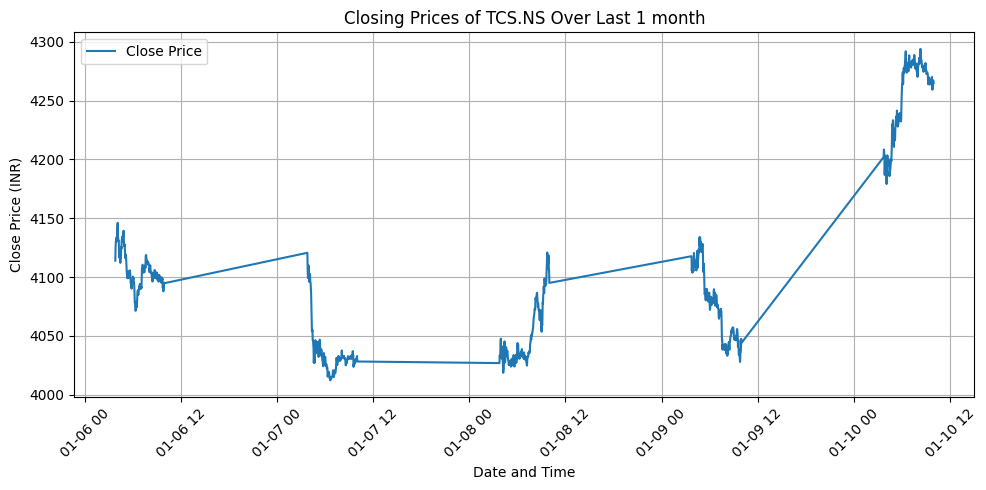

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df['Datetime'], df['Close'], label='Close Price')
plt.title(f'Closing Prices of {ticker_symbol} Over Last 1 month')
plt.xlabel('Date and Time')
plt.ylabel('Close Price (INR)')
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

### Data Split

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Scale data before splitting into train and test
scaled_data = scaler.fit_transform(df[['Close']].values)

# Train-test split
train_size = int(len(scaled_data) * 0.7)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# Prepare input-output sequences
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

SEQUENCE_LENGTH = 30  # Keep sequences long enough to capture trends
X_train, y_train = create_sequences(train_data, SEQUENCE_LENGTH)
X_test, y_test = create_sequences(test_data, SEQUENCE_LENGTH)


### Model Parameters

In [ ]:
# Model Hyperparameters
feature_dim = X_train.shape[2]  # Number of input features
num_heads = 4
num_layers = 2
hidden_dim = 128
dropout = 0.1

model = TimeSeriesTransformer(
    feature_dim=feature_dim,
    num_heads=2,  # Reduce attention heads
    num_layers=1,  # Fewer layers
    hidden_dim=64,  # Smaller hidden dimension
)


### Train the model

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

# Training loop
epochs = 100
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")


Epoch [10/100], Loss: 0.036529
Epoch [20/100], Loss: 0.029820
Epoch [30/100], Loss: 0.024010
Epoch [40/100], Loss: 0.017674
Epoch [50/100], Loss: 0.014517
Epoch [60/100], Loss: 0.011706
Epoch [70/100], Loss: 0.009474
Epoch [80/100], Loss: 0.007240
Epoch [90/100], Loss: 0.005729
Epoch [100/100], Loss: 0.005537


### Train the model

In [ ]:
# Make predictions
model.eval()
with torch.no_grad():
    predictions = model(X_test).numpy()

# Inverse transform the predictions
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.numpy())

### Predicted vs Actual:

This plot shows how well a regression model performs. If the predictions perfectly match the actual values, the points should align along a straight line with a slope of one. The closer the points cluster around this line, the more accurate the model's predictions are.

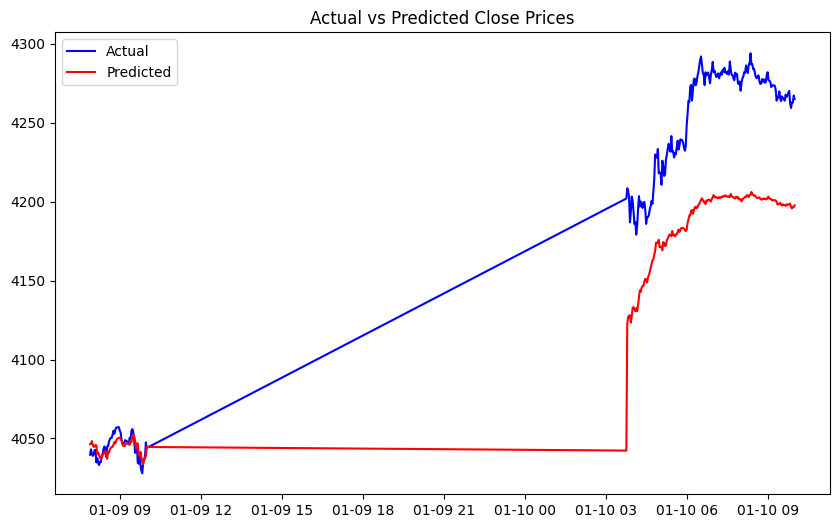

In [ ]:
datetime_test = df['Datetime'][-len(y_test_actual):]

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(datetime_test, y_test_actual, label="Actual", color="blue")
plt.plot(datetime_test, predictions, label="Predicted", color="red")
plt.title("Actual vs Predicted Close Prices")
plt.legend()
plt.show()

### Residual plot:

This plot offering insight into the relationship between observed and predicted values. Residuals distributed randomly around y = 0 indicate a well-captured data structure, whereas patterns or trends indicate model inadequacy. A good model will have residuals dispersed around zero, shown by a red dashed line. This plot is crucial tool in regression analysis.

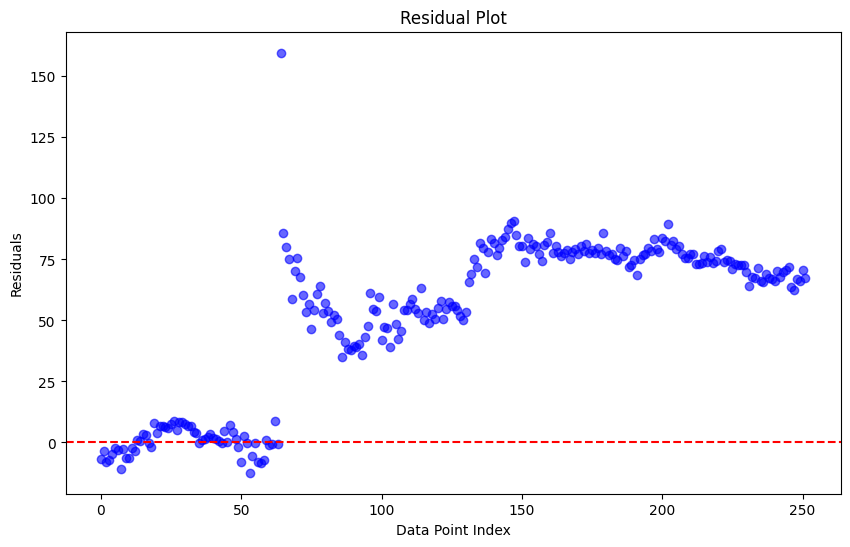

In [ ]:
import matplotlib.pyplot as plt

# Calculate residuals
residuals = y_test_actual.flatten() - predictions.flatten()

# Residual Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(range(len(residuals)), residuals, color="blue", alpha=0.6)
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Residual Plot")
plt.xlabel("Data Point Index")
plt.ylabel("Residuals")
plt.show()

### Residual Histogram

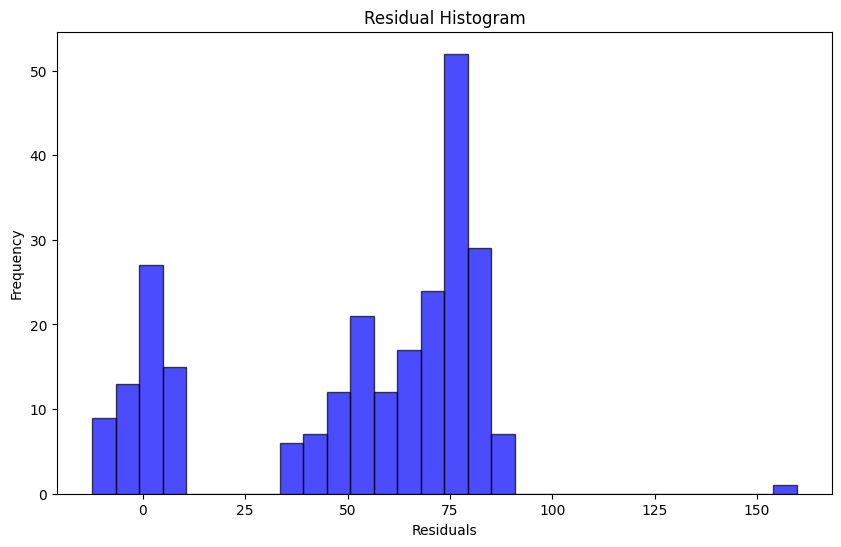

In [ ]:
# Residual Histogram
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, color="blue", edgecolor="black", alpha=0.7)
plt.title("Residual Histogram")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate MAPE
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100
print(f"Mean Absolute Percentage Error: {mape:.2f}%")

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print(f"Root Mean Squared Error: {rmse}")

# Calculate MAE
mae = mean_absolute_error(y_test_actual, predictions)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Percentage Error: 1.23%
Root Mean Squared Error: 60.61869127935603
Mean Absolute Error: 52.23307800292969


## 1 day

In [ ]:
df = yf.download(tickers=ticker_symbol)
df = df.reset_index()
df

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
0,2002-08-12,28.957355,29.176176,28.246185,28.246185,212976
1,2002-08-13,28.565300,29.458822,28.355597,28.993826,153576
2,2002-08-14,26.595903,28.629117,26.057966,28.629117,822776
3,2002-08-15,26.595903,26.595903,26.595903,26.595903,0
4,2002-08-16,26.532078,27.717360,26.076200,26.459138,811856
...,...,...,...,...,...,...
5560,2025-01-06,4095.000000,4149.649902,4066.399902,4105.500000,2085593
5561,2025-01-07,4028.300049,4140.350098,4011.550049,4114.950195,2669054
5562,2025-01-08,4108.399902,4126.000000,4017.750000,4034.899902,2181277


### Close value

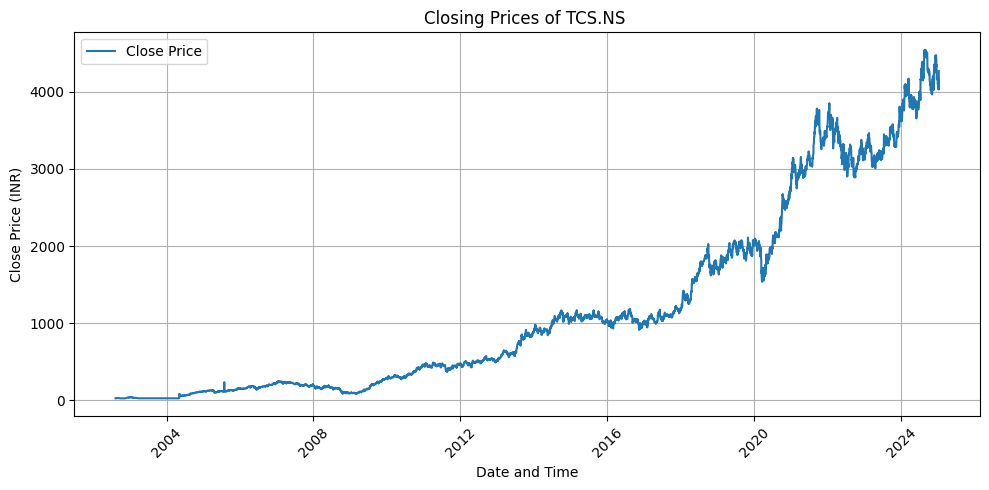

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.title(f'Closing Prices of {ticker_symbol} ')
plt.xlabel('Date and Time')
plt.ylabel('Close Price (INR)')
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

### Data Split

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Scale data before splitting into train and test
scaled_data = scaler.fit_transform(df[['Close']].values)

# Train-test split
train_size = int(len(scaled_data) * 0.7)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# Prepare input-output sequences
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

SEQUENCE_LENGTH = 20  # Keep sequences long enough to capture trends
X_train, y_train = create_sequences(train_data, SEQUENCE_LENGTH)
X_test, y_test = create_sequences(test_data, SEQUENCE_LENGTH)

### Model Parameters

In [ ]:
# Model Hyperparameters
feature_dim = X_train.shape[2]  # Number of input features
num_heads = 4
num_layers = 2
hidden_dim = 128
dropout = 0.1

model = TimeSeriesTransformer(
    feature_dim=feature_dim,
    num_heads=2,  # Reduce attention heads
    num_layers=1,  # Fewer layers
    hidden_dim=64,  # Smaller hidden dimension
)

### Train the model

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

# Training loop
epochs = 50
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")


Epoch [10/50], Loss: 0.120894
Epoch [20/50], Loss: 0.057020
Epoch [30/50], Loss: 0.029171
Epoch [40/50], Loss: 0.016843
Epoch [50/50], Loss: 0.012456


### Train the model

In [ ]:
# Make predictions
model.eval()
with torch.no_grad():
    predictions = model(X_test).numpy()

# Inverse transform the predictions
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.numpy())

### Predicted vs Actual:

This plot shows how well a regression model performs. If the predictions perfectly match the actual values, the points should align along a straight line with a slope of one. The closer the points cluster around this line, the more accurate the model's predictions are.

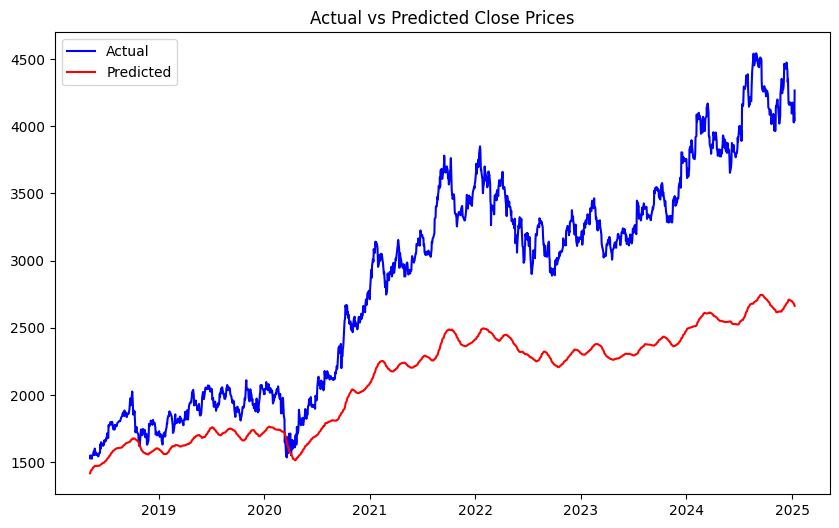

In [ ]:
datetime_test = df['Date'][-len(y_test_actual):]

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(datetime_test, y_test_actual, label="Actual", color="blue")
plt.plot(datetime_test, predictions, label="Predicted", color="red")
plt.title("Actual vs Predicted Close Prices")
plt.legend()
plt.show()

### Residual plot:

This plot offering insight into the relationship between observed and predicted values. Residuals distributed randomly around y = 0 indicate a well-captured data structure, whereas patterns or trends indicate model inadequacy. A good model will have residuals dispersed around zero, shown by a red dashed line. This plot is crucial tool in regression analysis.

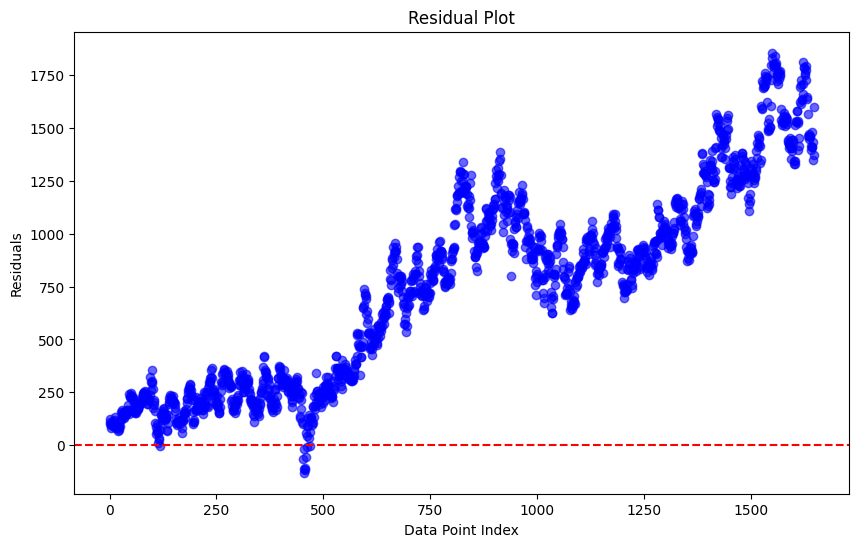

In [ ]:
import matplotlib.pyplot as plt

# Calculate residuals
residuals = y_test_actual.flatten() - predictions.flatten()

# Residual Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(range(len(residuals)), residuals, color="blue", alpha=0.6)
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Residual Plot")
plt.xlabel("Data Point Index")
plt.ylabel("Residuals")
plt.show()

### Residual Histogram

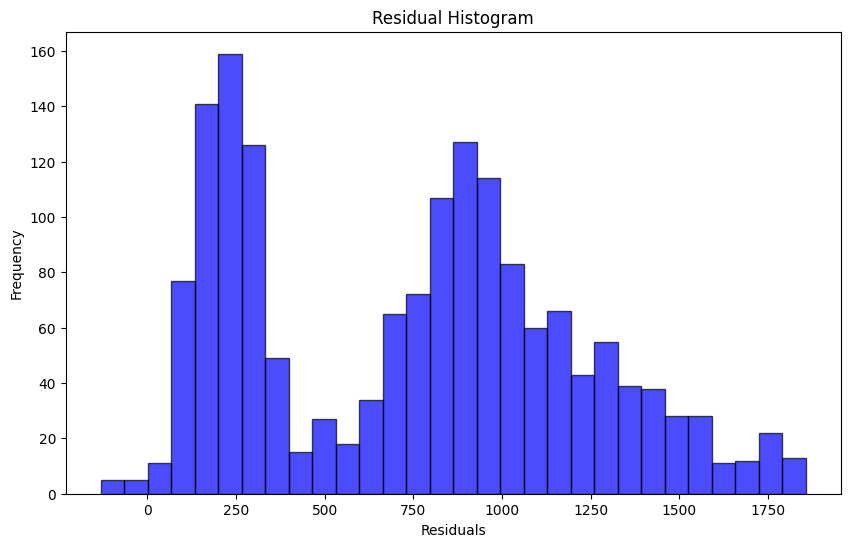

In [ ]:
# Residual Histogram
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, color="blue", edgecolor="black", alpha=0.7)
plt.title("Residual Histogram")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate MAPE
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100
print(f"Mean Absolute Percentage Error: {mape:.2f}%")

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print(f"Root Mean Squared Error: {rmse}")

# Calculate MAE
mae = mean_absolute_error(y_test_actual, predictions)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Percentage Error: 23.35%
Root Mean Squared Error: 879.0811253803598
Mean Absolute Error: 748.5888671875
